In [1]:
from multiprocessing import Pool
import subprocess
import yaml
import os
import sys
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import tempfile
import copy
from datetime import datetime
import pandas as pd
from collections import Counter
import numpy as np
import threading
import time

from sklearn.ensemble import GradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from sklearn.model_selection import GroupKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import roc_curve, auc
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss
from sklearn.isotonic import IsotonicRegression

from joblib import load
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader

from PIL import Image, ImageDraw, ImageFont
import matplotlib.pyplot as plt
import cv2

this_path = os.path.abspath(os.getcwd())
source_path = os.path.abspath(os.path.join(os.getcwd(), '..', '..'))
sys.path.append(source_path)

In [6]:
selected_FE = 'clip-vit-large-patch14-inter' #'DeiT-Tiny' #'resnet18'#'clip-vit-large-patch14'  # Example feature extractor, can be changed
dataset = 'iam' # 'icdar' or 'iam'
selected_metric='weighted_vote' #'weighted_vote' #'most_probable'

huggingface = global_vars.get_props(selected_FE).hugging
head_type = 'pytorch'  # 'sklearn' or 'pytorch' or none
use_test_private = True #if true evaluates on private, else on public

selected_classification_head = 'MLPClassifier1' #'logreg' #'MLPClassifier2'#'MLPClassifier1'#'TransformerClassifier'#'1DCNNClassifier'#'MLPClassifier2'
lang_train= '' #'ar' #if en only train on en, if ar only train on ar, if en+ar or '' train on both
lang_test = '' #'ar' #if en only test on en, if ar only test on ar, if en+ar or '' test on both
lang_sub = '_'+lang_train if lang_train in ['en', 'ar'] else ''
lang_test_sub = '_'+lang_test if lang_test in ['en', 'ar'] else ''


#test_private = file_IO.load_preprocessed_files(kind, 'test')
model_parameters = {
    'n_neurons':256,
    'hidden_sizes': [128],  # Hidden sizes for MLPClassifier2
    'dropout':0.6,
    'with_input_norm': 'batch_norm',  # Whether to use input normalization 'batch_norm' , None
    'mean': None,  # Mean for input normalization
    'scale': None,  # Scale for input normalization
    'activation': 'relu'
}

#creating current directory where i will save evaluation results for the current model
#only one current folder for each model,custom_pretrained combination -> new results will overwrite these
models_dir = os.path.join(this_path, 'models', selected_FE)
load_dir = os.path.join(models_dir,f'torch_model_trained_on_rep{lang_sub}',f'{selected_classification_head}',dataset)

search_dir=load_dir+'/current/'
file_IO.access_or_create_dir(search_dir)

data_augmentation = False
suffix = '_augmented' if data_augmentation else ''
kind = 'patches_224'  # Example kind, can be changed


use_external_validation = True
if use_external_validation:
    validation_mode = 'val_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
else:
    validation_mode = '1fold_train_only'  # 'kfold_train_only', 'val_only', '1fold_train_only'
#see from training logs ad set by hand
extra_view=False
extra_integration_mode = 'concat'  # 'concat' or 'add'
aggregation_mode = None #'mean'  # 'mean' or 'max'
extra_train_filename, extra_val_filename = None, None

list_of_metrics = ['majority_vote', 'weighted_vote', 'most_probable']
if kind == 'body':
    selected_metric = 'most_probable'  # Use the metric you want to analyze

In [7]:
calibrate=True
threshold=0.5

train_filename,val_filename, test_filename = [
    models_dir+f'/{selected_FE}_features_{dataset}_train_df_w_patches.csv',
    models_dir+f'/{selected_FE}_features_{dataset}_public_df_w_patches.csv',
    models_dir+f'/{selected_FE}_features_{dataset}_private_df_w_patches.csv'
]
mean,scale = model_utils.get_normalization_parameters(train_filename) 
model_parameters['mean']=mean
model_parameters['scale']=scale

classification_head, val_df = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,
                                                                validation_mode,train_filename, source_path,**model_parameters,
                                                                custom_pretrained='original', lang=lang_sub, search_dir=load_dir)
if use_external_validation:
    if use_test_private:
        val_df = pd.read_csv(test_filename)
    else:
        val_df = pd.read_csv(val_filename) 
    val_df['train'] = 0  # Mark validation data
if extra_view:
    val_df_extra = pd.read_csv(extra_val_filename)
    if not(use_external_validation):
        _, val_df_extra = data_loading.load_classification_head(selected_FE,selected_classification_head,head_type,
                                                                validation_mode,extra_train_filename,source_path, lang=lang_sub, 
                                                                search_dir=load_dir)
    val_df = dataframes.merge_dfs(val_df, val_df_extra, mode=extra_integration_mode)
val_df = dataframes.aggregate_dfs(val_df,mode=aggregation_mode)

if lang_test == 'en':
    val_df = val_df[val_df['isEng'] == 1]
elif lang_test == 'ar':
    val_df = val_df[val_df['isEng'] == 0]

# Keep only 5 patches per page
#val_df_test = val_df.groupby('page').head(40).reset_index(drop=True)

#if calibration is active i need to calibrate on the validation and apply on the test
if calibrate:
    cal_df = pd.read_csv(val_filename)
    if lang_test == 'en':
        cal_df = cal_df[cal_df['isEng'] == 1]
    elif lang_test == 'ar':
        cal_df = cal_df[cal_df['isEng'] == 0]
    from sklearn.isotonic import IsotonicRegression
    iso = IsotonicRegression(out_of_bounds='clip')
    cols_to_drop_temp = [c for c in cal_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
    if head_type == 'pytorch':
        classification_head.eval()
        with torch.no_grad():
            X_train = torch.tensor(cal_df.drop(columns=cols_to_drop_temp).values, dtype=torch.float32)
            logits = classification_head(X_train)  # shape: [N, 2]
            probs = F.softmax(logits, dim=1)  # shape: [N, 2]
            y_prob = probs[:, 1].numpy()  # probability of class 1
    else:
        y_prob = classification_head.predict_proba(cal_df.drop(columns=cols_to_drop_temp).values)[:,1]
    iso.fit(y_prob, cal_df['male'])
else:
    iso = None

#res_df=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=True,threshold=0.5)
res_df,out_results=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df, head_type,calibrate=calibrate,
                                                                            threshold=threshold, list_of_metrics=list_of_metrics,out_iso=iso)
print(res_df.columns)
print(out_results)

file_IO.save_dict_to_txt(out_results, search_dir + f"accuracies_on_test_set{lang_test_sub}.txt")

aggregating patches, length before: 9293
length after: 9293
Index(['file_name', 'writer', 'male', 'isEng', 'same_text', 'form_id', 'x',
       'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train',
       'y_prob', 'y_pred', 'grouped_true', 'majority_vote',
       'majority_vote_uncertainty', 'weighted_vote',
       'weighted_vote_uncertainty', 'most_probable',
       'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer'],
      dtype='object')
{'Accuracy for individual patches': 0.7056924566878295, 'Accuracy for majority_vote': 0.7084902614871409, 'Accuracy for weighted_vote': 0.7214032067147316, 'Accuracy for most_probable': 0.740126977294738, 'Accuracy for writer level prediction': 0.7358490566037735}


In [45]:
print("Number of unique pages in the validation set:", val_df['page'].nunique())
print("Number of unique writers in the validation set:", val_df['writer'].nunique())
print("Length of validation set:", len(val_df), "Patches per page:", len(val_df)/val_df['page'].nunique())
for f in [0.1,0.3,0.5,0.7,1]:
    val_df_partial = val_df.copy()
    #for each page keep only a fraction f (at random) of the rows with the same page number
    val_df_partial = val_df_partial.groupby('page').apply(lambda x: x.sample(frac=f, random_state=42)).reset_index(drop=True)
    print("="*50)
    print(f"Number of unique pages in the validation set for fraction {f}:", val_df_partial['page'].nunique())
    print(f"Length of validation set for fraction {f}:", len(val_df_partial), "Patches per page:", len(val_df_partial)/val_df_partial['page'].nunique())
    _,out_results_temp=evaluation_utils.compute_predictions_and_uncertainties(classification_head, val_df_partial, head_type,calibrate=calibrate,
                                                                            threshold=threshold, list_of_metrics=list_of_metrics,out_iso=iso)
    print(f"Results for fraction {f}: {out_results_temp['Accuracy for majority_vote'],out_results_temp['Accuracy for weighted_vote']}")

Number of unique pages in the validation set: 488
Number of unique writers in the validation set: 122
Length of validation set: 19520 Patches per page: 40.0
Number of unique pages in the validation set for fraction 0.1: 488
Length of validation set for fraction 0.1: 1952 Patches per page: 4.0
Results for fraction 0.1: (0.7725409836065574, 0.7745901639344263)
Number of unique pages in the validation set for fraction 0.3: 488
Length of validation set for fraction 0.3: 5856 Patches per page: 12.0
Results for fraction 0.3: (0.8073770491803278, 0.8012295081967213)
Number of unique pages in the validation set for fraction 0.5: 488
Length of validation set for fraction 0.5: 9760 Patches per page: 20.0
Results for fraction 0.5: (0.8032786885245902, 0.7991803278688525)
Number of unique pages in the validation set for fraction 0.7: 488
Length of validation set for fraction 0.7: 13664 Patches per page: 28.0
Results for fraction 0.7: (0.8012295081967213, 0.8073770491803278)
Number of unique pages 

## others

In [8]:
args = script_launching.DotDict(
    custom_pretrained = 'original',
    evaluation_mode = 'backbone_only',  
    selected_FE=selected_FE,
    selected_classification_head=selected_classification_head,
    model_parameters={k: v for k, v in model_parameters.items() if k not in ['mean', 'scale']},
    head_type=head_type,
    use_external_validation=use_external_validation,
    validation_mode=validation_mode,
    data_augmentation=data_augmentation,
    extra_view=extra_view,
    extra_integration_mode=extra_integration_mode,
    aggregation_mode=aggregation_mode,
    train_filename=train_filename,
    val_filename=val_filename,
    extra_train_filename=extra_train_filename,
    extra_val_filename=extra_val_filename,
    selected_metric=selected_metric,
    calibrate=calibrate,
    threshold=threshold,
    num_workers=0,
    pin_memory=True,
    lang_test=lang_test,
    lang_train=lang_train,
    #script_mode='standalone'
    )
file_IO.save_args(args,search_dir)  # Save the arguments to a file

## sub-accuracy on wrong and correct pages

In [9]:
failed=res_df[res_df['weighted_vote']!= res_df['grouped_true']]
correct = res_df[res_df['weighted_vote'] == res_df['grouped_true']]
failed_pages = failed['page'].unique()
out_results={}
out_results['num_failed_predictions']=len(failed)
out_results['num_correct_predictions']=len(correct)
out_results['num_failed_pages']=len(failed_pages)
out_results['num_correct_pages']=len(correct['page'].unique())
out_results['accuracy_on_failed']=len(failed[failed['male']==failed['y_pred']])/len(failed)
out_results['accuracy_on_correct']=len(correct[correct['male']==correct['y_pred']])/len(correct)
print(out_results)
file_IO.save_dict_to_txt(out_results, search_dir + "sub_accuracies.txt")

{'num_failed_predictions': 2589, 'num_correct_predictions': 6704, 'num_failed_pages': 121, 'num_correct_pages': 326, 'accuracy_on_failed': 0.09192738509076864, 'accuracy_on_correct': 0.9427207637231504}


In [10]:
display(failed[failed['page'] == 16][[selected_metric,selected_metric+'_uncertainty', 'grouped_true', 'y_prob', 'y_pred']].sort_values(by='y_prob', ascending=False))

,weighted_vote,weighted_vote_uncertainty,grouped_true,y_prob,y_pred
280,1,1.0,0,1.000000,1
274,1,1.0,0,0.985714,1
276,1,1.0,0,0.958944,1
281,1,1.0,0,0.958944,1
279,1,1.0,0,0.958944,1
277,1,1.0,0,0.958944,1
271,1,1.0,0,0.958944,1
283,1,1.0,0,0.958944,1
282,1,1.0,0,0.958944,1
284,1,1.0,0,0.958944,1


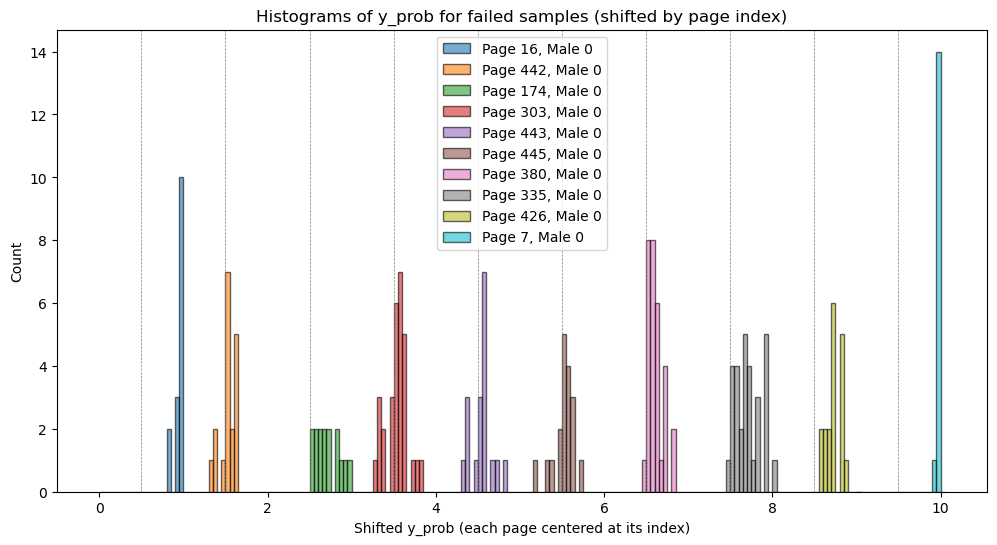

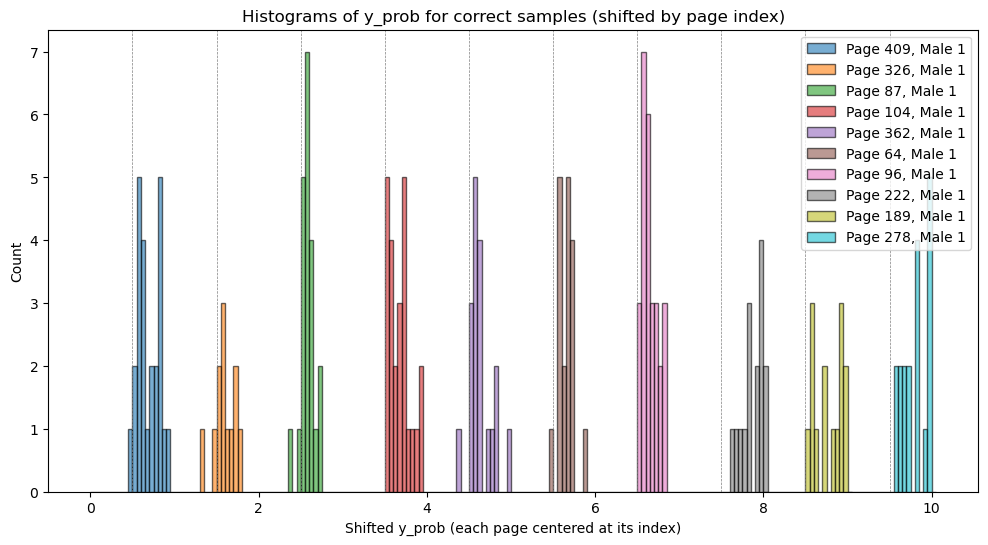

In [11]:
def display_pred_distribution(failed, failed_pages,num_pages=15,title='failed'):
    plt.figure(figsize=(12, 6))
    bin_width = 0.05
    np.random.shuffle(failed_pages)
    for i, page in enumerate(failed_pages[:num_pages]):
        subset = failed[failed['page'] == page]['y_prob']
        isMale = failed[failed['page'] == page]['grouped_true'].iloc[0]
        # Shift the histogram center by page number (e.g., offset by i)
        shifted = subset + i
        plt.hist(shifted, bins=np.arange(i, i + 1 + bin_width, bin_width), alpha=0.6, edgecolor='black', label=f'Page {page}, Male {isMale}')
        # Mark the center for each page
        plt.axvline(i + 0.5, color='gray', linestyle='--', linewidth=0.5)

    plt.title(f'Histograms of y_prob for {title} samples (shifted by page index)')
    plt.xlabel('Shifted y_prob (each page centered at its index)')
    plt.ylabel('Count')
    plt.legend()
    plt.savefig(os.path.join(search_dir, f"pred_distribution_{title}.png"))
    plt.show()
display_pred_distribution(failed, failed_pages,num_pages=10,title='failed')
display_pred_distribution(correct, correct['page'].unique(),num_pages=10,title='correct')

In [12]:
cols_to_drop = [c for c in res_df.columns if not(c.startswith('f') and len(c) > 1 and c[1].isdigit())]
print(f"Columns to drop: {cols_to_drop}")
c_of_interest=['page','male','y_pred','y_prob','grouped_true','weighted_vote','majority_vote','weighted_vote_uncertainty']
test = res_df[c_of_interest].copy()
display(test[test['page'] == 60])

Columns to drop: ['file_name', 'writer', 'male', 'isEng', 'same_text', 'form_id', 'x', 'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train', 'y_prob', 'y_pred', 'grouped_true', 'majority_vote', 'majority_vote_uncertainty', 'weighted_vote', 'weighted_vote_uncertainty', 'most_probable', 'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer']


,page,male,y_pred,y_prob,grouped_true,weighted_vote,majority_vote,weighted_vote_uncertainty
1131,60,0,1,0.900000,0,1,1.0,0.930043
1132,60,0,1,0.615917,0,1,1.0,0.930043
1133,60,0,1,0.834586,0,1,1.0,0.930043
1134,60,0,1,0.709220,0,1,1.0,0.930043
1135,60,0,1,0.900990,0,1,1.0,0.930043
1136,60,0,1,0.627040,0,1,1.0,0.930043
1137,60,0,1,0.834586,0,1,1.0,0.930043
1138,60,0,1,0.916667,0,1,1.0,0.930043
1139,60,0,1,0.900990,0,1,1.0,0.930043
1140,60,0,0,0.361963,0,1,1.0,0.930043


## descriptive statistics

In [13]:
res_df.columns

Index(['file_name', 'writer', 'male', 'isEng', 'same_text', 'form_id', 'x',
       'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train',
       'y_prob', 'y_pred', 'grouped_true', 'majority_vote',
       'majority_vote_uncertainty', 'weighted_vote',
       'weighted_vote_uncertainty', 'most_probable',
       'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer'],
      dtype='object')

9293
9293
9293
9293
9293


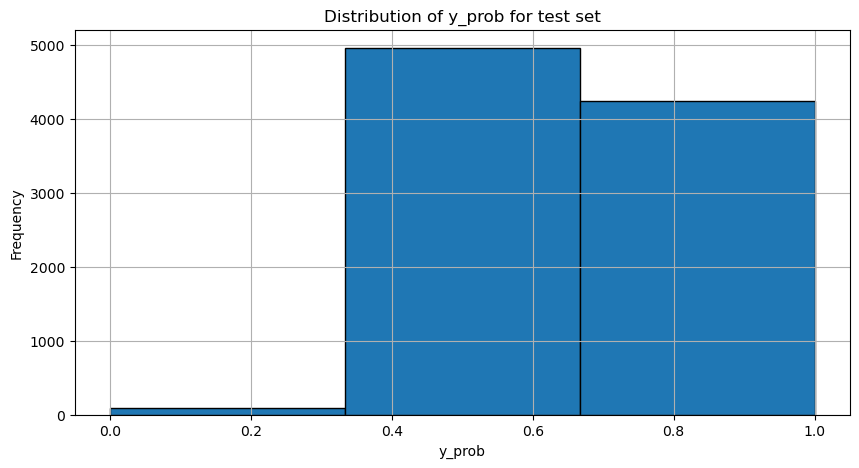

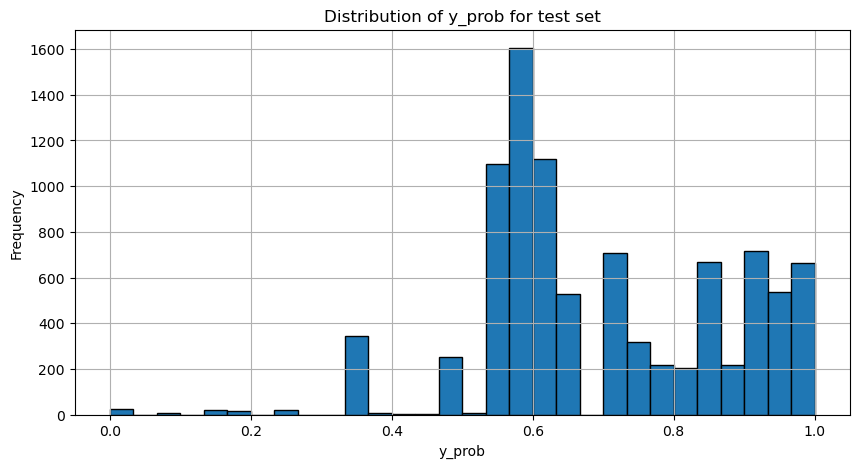

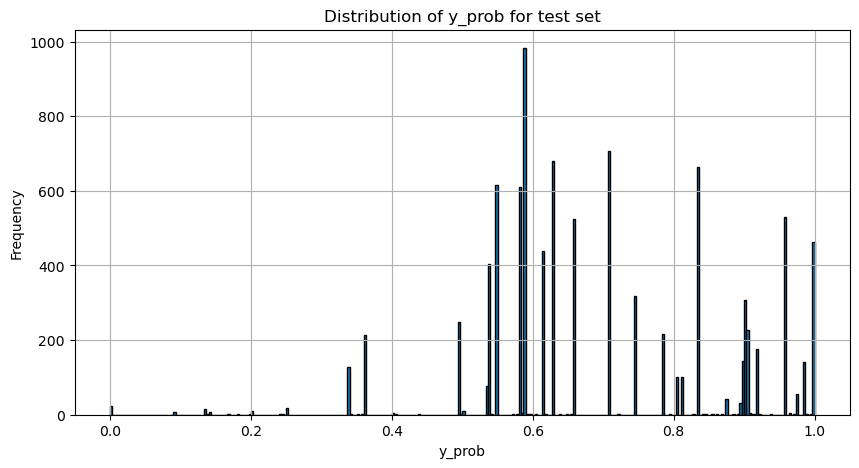

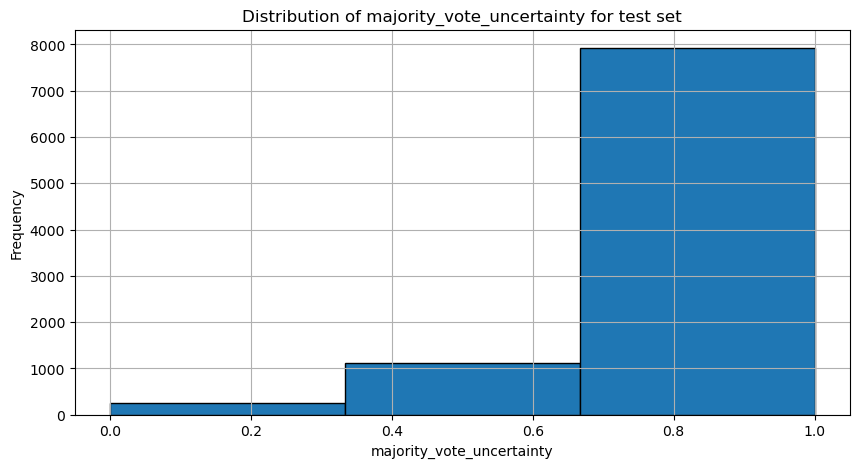

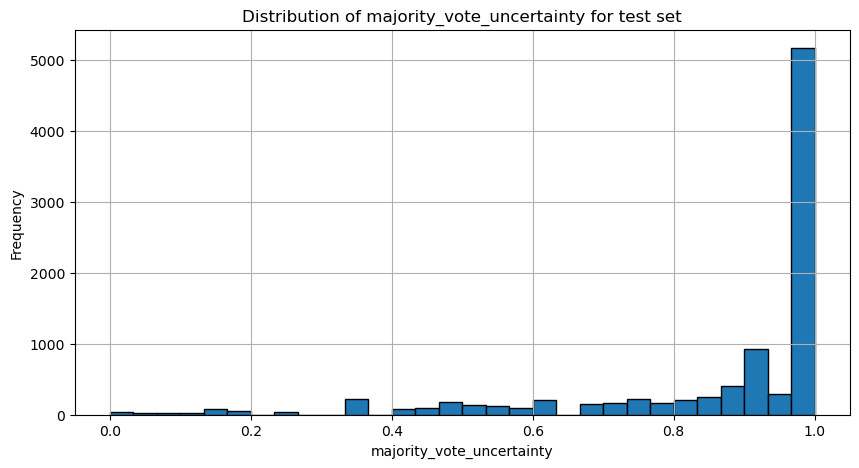

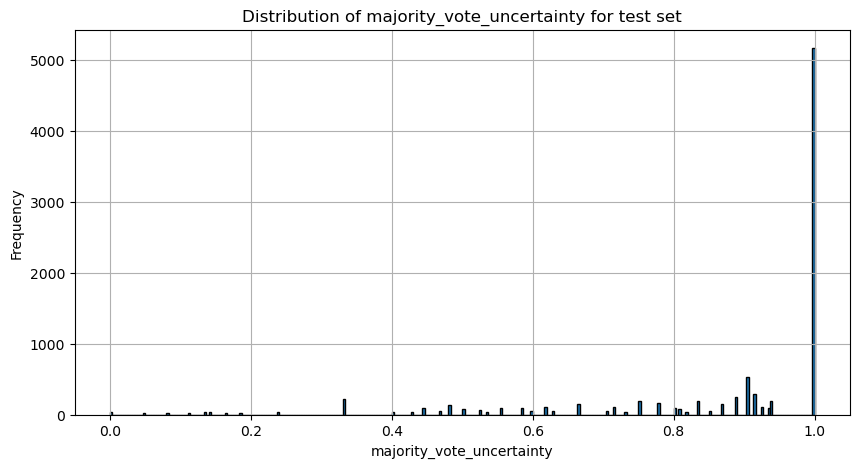

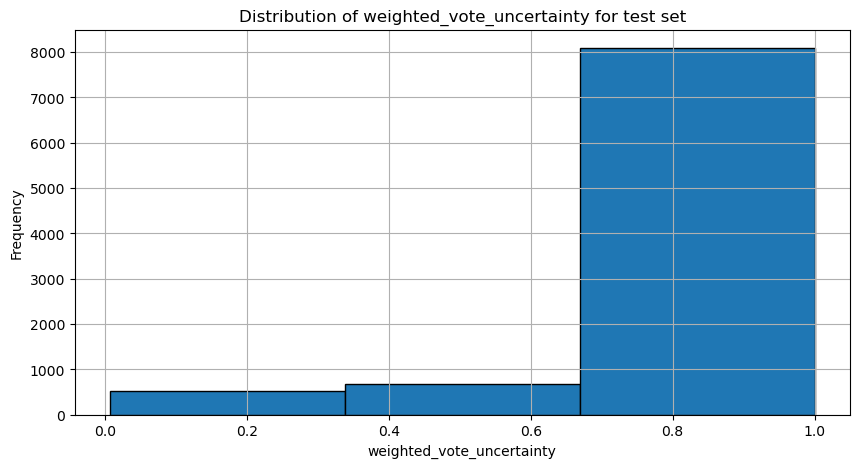

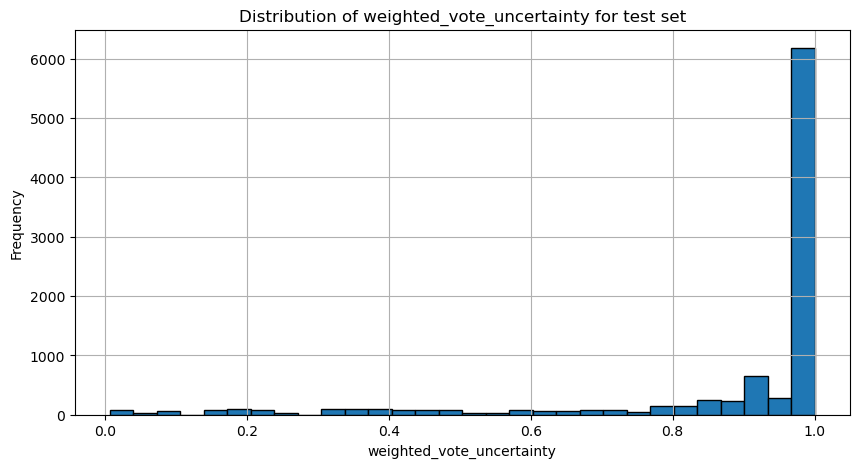

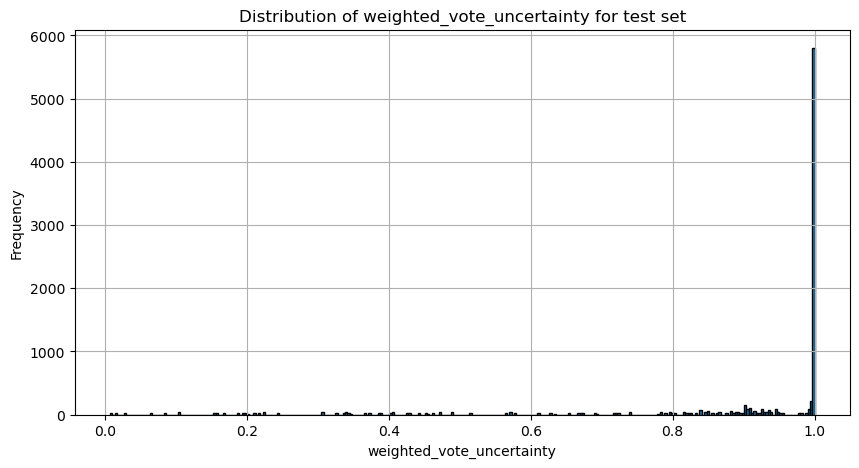

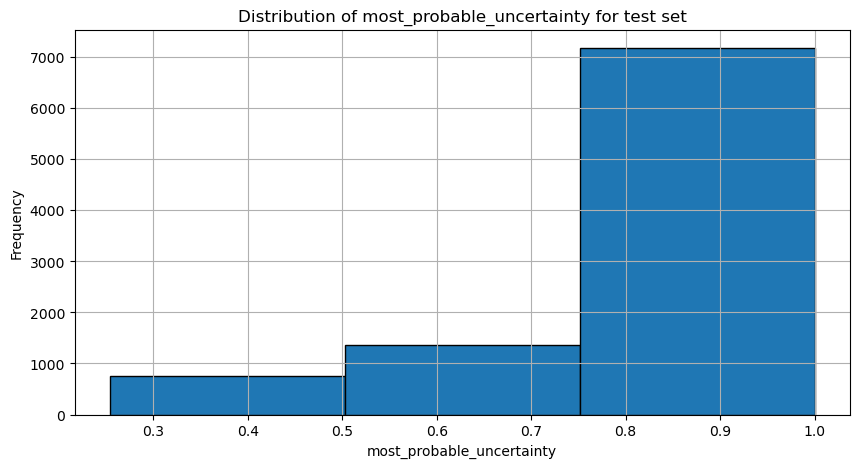

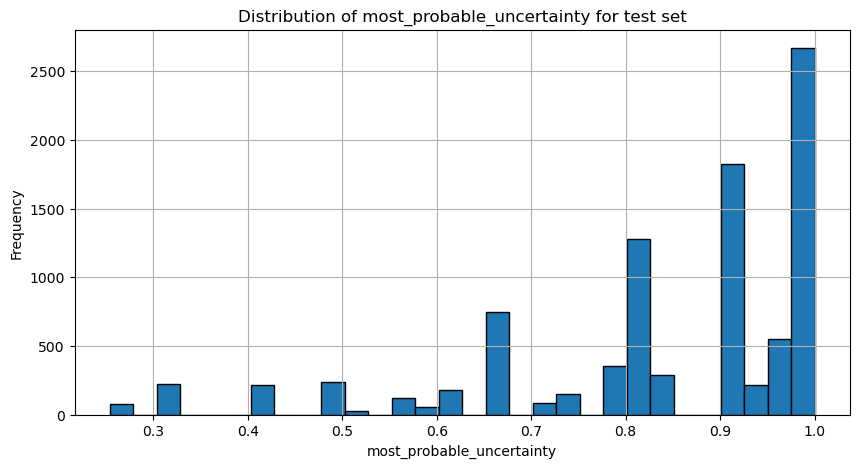

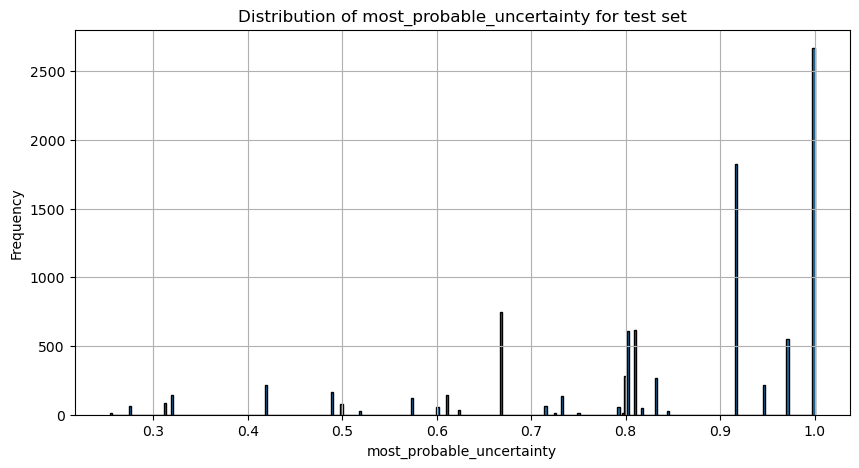

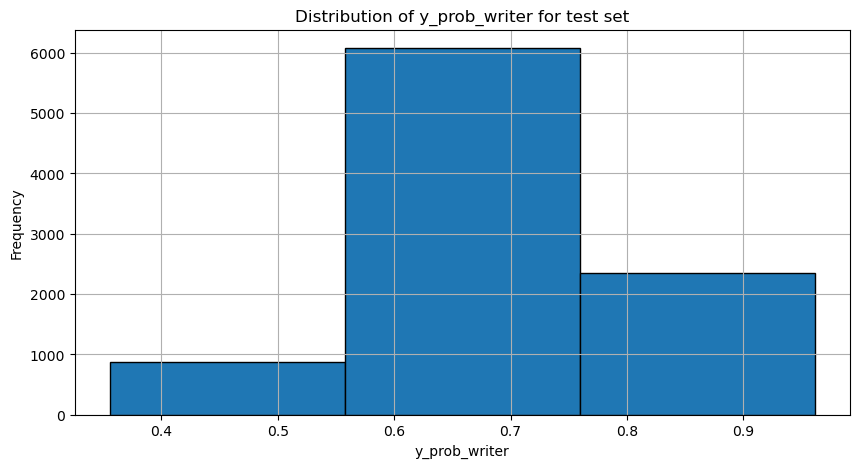

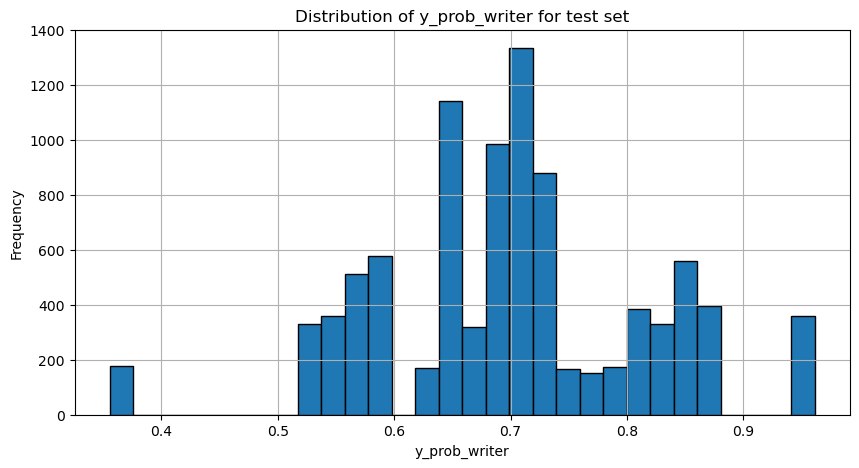

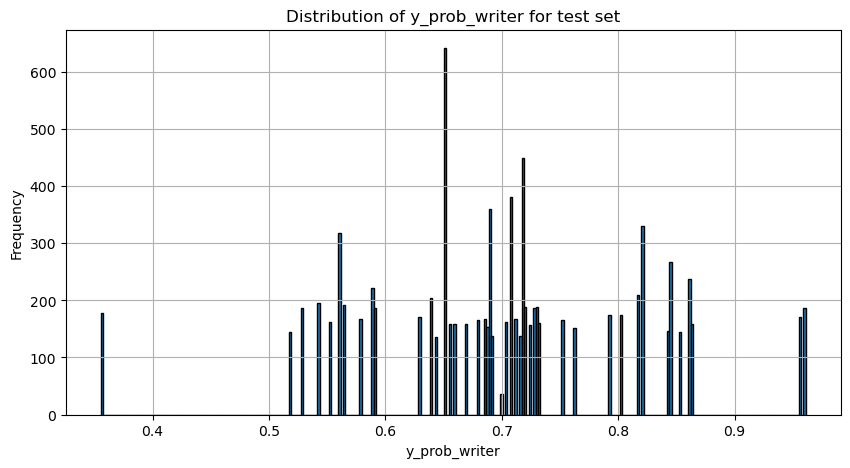

In [14]:
#probability distribution
import matplotlib.pyplot as plt
display_df=res_df[res_df['train']==0][['y_prob','majority_vote_uncertainty','weighted_vote_uncertainty','most_probable_uncertainty','y_prob_writer']].describe()
file_IO.save_df_to_png(display_df, os.path.join(search_dir, "uncertainty_table.png"))

def plot_prob_distribution(res_df,save_dir,prob_column='y_prob',bins=30):
    file_IO.access_or_create_dir(save_dir)
    plt.figure(figsize=(10, 5))
    res_df[res_df['train']==0][prob_column].hist(bins=bins, edgecolor='black')
    plt.title(f'Distribution of {prob_column} for test set')
    plt.xlabel(prob_column)
    plt.ylabel('Frequency')
    plt.savefig(os.path.join(save_dir, f"{prob_column}_prob_distribution_nbins_{bins}.png"))
    #plt.show()
prob_columns = ['y_prob','majority_vote_uncertainty','weighted_vote_uncertainty','most_probable_uncertainty','y_prob_writer']
for p_column in prob_columns:
    #temp_df=res_df.groupby('page').first()
    temp_df=res_df.copy()
    print(len(temp_df))
    for i in range(3):
        plot_prob_distribution(temp_df,save_dir=search_dir+'prob_distribution/', prob_column=p_column, bins=3*10**i)

In [15]:
#TPR=Recall=TP/(TP + FN)
#FPR=FP/(FP + TN)

# Sample confusion matrix
labels = ['female', 'male']

# confusion matrix page level
grouped_res = res_df[res_df['train']==0].groupby('page').first()
true_values = grouped_res['grouped_true']



save_dir = search_dir+'confusion_matrices/'
save_dir_2 = search_dir+'roc_auc/'
save_dir_3 = search_dir+'calibration_curves/'
file_IO.access_or_create_dir(save_dir)
file_IO.access_or_create_dir(save_dir_2)
file_IO.access_or_create_dir(save_dir_3)
for metric in list_of_metrics:
    pred_values = grouped_res[metric]
    prob_values = grouped_res[f'{metric}_uncertainty']
    for i,p in enumerate(prob_values): #some values in weighted uncertainty are >1
        if p>1:
            prob_values[i] = 1
    plot_confusion_matrix(true_values, pred_values, save_dir, label_names=labels, labels=[0,1], level='page', metric=metric)
    roc_auc(true_values, prob_values, save_dir_2, level='page', metric=metric)
    plot_calibration_with_metrics(
        true_values,
        prob_values,
        n_bins=10,
        pos_label=1,
        title="Calibration Curves (Uncalibrated vs Isotonic)",
        save_path=save_dir_3,
        show=False,
        level='patch', 
        metric=metric
    )

# confusion matrix patch level
grouped_res = res_df[res_df['train']==0]
true_values = grouped_res['grouped_true']
pred_values = grouped_res['y_pred']
prob_values = grouped_res['y_prob']
plot_confusion_matrix(true_values, pred_values, save_dir, label_names=labels, labels=[0,1], level='patch', metric='individual')
roc_auc(true_values, prob_values, save_dir_2, level='patch', metric='individual')
plot_calibration_with_metrics(
    true_values,
    prob_values,
    n_bins=10,
    pos_label=1,
    title="Calibration Curves (Uncalibrated vs Isotonic)",
    save_path=save_dir_3,
    show=False,
    level='patch',
    metric='individual'
)

# confusion matrix writer
grouped_res = res_df[res_df['train']==0].groupby('writer').first()
true_values = grouped_res['grouped_true']
pred_values = grouped_res['y_pred_writer']
prob_values = grouped_res['y_prob_writer']
plot_confusion_matrix(true_values, pred_values, save_dir, label_names=labels, labels=[0,1], level='writer', metric='average')
roc_auc(true_values, prob_values, save_dir_2, level='writer', metric='average')
plot_calibration_with_metrics(
    true_values,
    prob_values,
    n_bins=10,
    pos_label=1,
    title="Calibration Curves (Uncalibrated vs Isotonic)",
    save_path=save_dir_3,
    show=False,
    level='writer',
    metric='average'
)


(<Figure size 1200x600 with 2 Axes>,
 array([<Axes: title={'center': 'Uncalibrated'}, xlabel='Predicted Probability', ylabel='True Probability'>,
        <Axes: title={'center': 'Isotonic-calibrated'}, xlabel='Predicted Probability', ylabel='True Probability'>],
       dtype=object))

## misclassified samples (images)

In [16]:
class_split_page = evaluation_utils.group_instances(res_df,level='page',list_of_metrics=list_of_metrics)
print(class_split_page.columns)
class_split_patch = evaluation_utils.group_instances(res_df,level='patch',list_of_metrics=list_of_metrics)
print(class_split_patch.columns)

Index(['file_name', 'writer', 'male', 'isEng', 'same_text', 'form_id', 'x',
       'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train',
       'y_prob', 'y_pred', 'grouped_true', 'majority_vote',
       'majority_vote_uncertainty', 'weighted_vote',
       'weighted_vote_uncertainty', 'most_probable',
       'most_probable_uncertainty', 'y_pred_writer', 'y_prob_writer',
       'majority_vote_selected', 'majority_vote_sure', 'majority_vote_unsure',
       'majority_vote_ok', 'weighted_vote_selected', 'weighted_vote_sure',
       'weighted_vote_unsure', 'weighted_vote_ok', 'most_probable_selected',
       'most_probable_sure', 'most_probable_unsure', 'most_probable_ok'],
      dtype='object')
Index(['file_name', 'writer', 'male', 'isEng', 'same_text', 'form_id', 'x',
       'y', 'x2', 'y2', 'n_cc', 'black_ratio', 'index', 'page', 'train',
       'y_prob', 'y_pred', 'grouped_true', 'majority_vote',
       'majority_vote_uncertainty', 'weighted_vote',
       'weighted_vote_unce

In [17]:
unsure_ok_true = evaluation_utils.select_instances(class_split_page, metric='weighted_vote', sure=0, unsure=1, ok=1,true=1, n_samples=1)

## select instances

In [18]:
selected = evaluation_utils.select_for_explanation(class_split_page, selected_metric)

,weighted_vote_sure,weighted_vote_unsure,weighted_vote_ok,grouped_true
page,,,,
352,0,0,0,0
345,0,0,1,0
198,0,0,1,1
385,0,1,0,0
388,0,1,1,0
329,0,1,1,1
340,1,0,0,0
132,1,0,1,1


In [19]:
selected_pages=list(selected['page'])
all_selected_patches=class_split_page[class_split_page['page'].isin(selected_pages)]

In [20]:
all_selected_patches.to_csv(search_dir+f'selected_instances_{selected_metric}.csv', index=False)

In [21]:
len(selected)

8

# reload

In [2]:
def reload_modules():
    import importlib
    import utils.data_loading as data_loading
    import utils.visualization as visualization
    import utils.dataframes as dataframes
    import utils.utils_transforms as u_transforms
    import utils.training_utils as training_utils
    import utils.model_utils as model_utils
    import utils.file_IO as file_IO
    import utils.vit_rollout_mod as vit_rollout_mod
    import utils.evaluation_utils as evaluation_utils
    import utils.script_launching as script_launching
    import utils.global_vars as global_vars
    
    importlib.reload(file_IO)
    importlib.reload(data_loading)
    importlib.reload(visualization)
    importlib.reload(dataframes)
    importlib.reload(u_transforms)
    importlib.reload(model_utils)
    importlib.reload(training_utils)
    importlib.reload(vit_rollout_mod)
    importlib.reload(evaluation_utils)
    importlib.reload(script_launching)
    importlib.reload(global_vars)

    return data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching, global_vars
data_loading, visualization, dataframes, u_transforms, training_utils, model_utils, file_IO, vit_rollout_mod, evaluation_utils, script_launching, global_vars = reload_modules()

In [3]:
def plot_calibration_with_metrics(
    true_values,
    prob_values,
    n_bins=10,
    pos_label=1,
    title="Calibration Curves (Uncalibrated vs Isotonic)",
    save_path=None,
    show=True,
    level='patch',metric='average'
):
    """
    Plots side-by-side calibration diagrams for:
      - Uncalibrated probabilities
      - Isotonic-calibrated probabilities

    Also stamps Brier scores and Acc@0.5 for both on the same figure.

    Parameters
    ----------
    true_values : array-like of shape (n_samples,)
        Ground-truth binary labels (0/1). Ensure 'pos_label' matches the positive class.
    prob_values : array-like of shape (n_samples,)
        Predicted probabilities for the positive class.
    n_bins : int, default=10
        Number of bins for reliability diagram.
    pos_label : int or str, default=1
        Positive class label (used by Brier score).
    title : str
        Suptitle for the figure.
    save_path : str or None
        If provided, saves the figure to this path.
    show : bool
        If True, calls plt.show() at the end.

    Returns
    -------
    fig, axes
    """
    y = np.asarray(true_values)
    p = np.asarray(prob_values, dtype=float)

    # Drop NaNs in probabilities (keep alignment)
    mask = ~np.isnan(p)
    y, p = y[mask], p[mask]

    # --- Uncalibrated ---
    pt_u, pp_u = calibration_curve(y, p, n_bins=n_bins)
    brier_u = brier_score_loss(y, p, pos_label=pos_label)
    acc_u   = accuracy_score(y, (p >= 0.5).astype(int))

    # --- Isotonic-calibrated ---
    iso = IsotonicRegression(out_of_bounds='clip')
    iso.fit(p, y)
    p_cal = iso.predict(p)

    pt_c, pp_c = calibration_curve(y, p_cal, n_bins=n_bins)
    brier_c = brier_score_loss(y, p_cal, pos_label=pos_label)
    acc_c   = accuracy_score(y, (p_cal >= 0.5).astype(int))

    # --- Figure ---
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharex=True, sharey=True)
    for ax, pp, pt, subtitle in [
        (axes[0], pp_u, pt_u, "Uncalibrated"),
        (axes[1], pp_c, pt_c, "Isotonic-calibrated"),
    ]:
        ax.plot(pp, pt, marker='o', label='Model')
        ax.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfectly calibrated')
        ax.set_xlabel('Predicted Probability')
        ax.set_ylabel('True Probability')
        ax.set_title(subtitle)
        ax.grid(True)
    axes[0].legend(loc='upper left')
    fig.suptitle(title, y=0.98)

    # --- “prints” embedded as a textbox ---
    text = (
        f"Brier (uncal.): {brier_u:.4f}   Acc@0.5 (uncal.): {acc_u:.4f}\n"
        f"Brier (cal.):   {brier_c:.4f}   Acc@0.5 (cal.):   {acc_c:.4f}\n"
        f"n={len(y)}, bins={n_bins}, positive label={pos_label}"
    )
    fig.subplots_adjust(bottom=0.22)
    fig.text(
        0.5, 0.03, text,
        ha='center', va='bottom', fontsize=10,
        family='monospace',
        bbox=dict(boxstyle='round,pad=0.3', fc='white', ec='0.8', alpha=0.95)
    )

    if save_path:
        fig.savefig(save_path+f'{level}_calibration_curve_{metric}.png', dpi=200, bbox_inches='tight')
    if show:
        plt.show()
    else:
        plt.close(fig)

    return fig, axes


def plot_confusion_matrix(
    true_values,
    pred_values,
    save_dir,
    label_names=None,   # e.g., ['female','male']
    labels=None,        # e.g., [0, 1]
    level='page',
    metric='individual'
):
    import os, numpy as np, matplotlib.pyplot as plt, seaborn as sns
    from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, balanced_accuracy_score
    from sklearn.utils.multiclass import unique_labels

    # Defaults if not provided
    if labels is None:
        labels = unique_labels(true_values, pred_values)
    if label_names is None:
        label_names = [str(x) for x in labels]
    else:
        label_names = [str(x) for x in label_names]

    # Confusion matrix (fixed order)
    conf = confusion_matrix(true_values, pred_values, labels=labels)

    # Totals
    row_sums = conf.sum(axis=1, keepdims=True)
    col_sums = conf.sum(axis=0, keepdims=True)
    total = conf.sum() if conf.size else 0

    # Extended matrix with totals
    conf_ext = np.vstack([conf, col_sums])
    conf_ext = np.hstack([conf_ext, np.append(row_sums, total).reshape(-1, 1)])

    # Percentages of total (guard divide-by-zero)
    conf_ext_percent = (conf_ext / total * 100) if total else np.zeros_like(conf_ext, dtype=float)

    # Annotations
    annot = np.empty_like(conf_ext, dtype=object)
    for i in range(conf_ext.shape[0]):
        for j in range(conf_ext.shape[1]):
            count = int(conf_ext[i, j])
            percent = conf_ext_percent[i, j]
            annot[i, j] = f'{percent:.1f}%\n({count})'

    # Ticks
    xticks = list(label_names) + ['Total']
    yticks = list(label_names) + ['Total']

    # Figure
    fig, ax = plt.subplots(figsize=(10, 10))
    sns.heatmap(
        conf_ext_percent, annot=annot, fmt='',
        cmap='Blues', xticklabels=xticks, yticklabels=yticks,
        cbar_kws={"label": "% of all samples"}, ax=ax
    )
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_title(f"Confusion Matrix with Totals — {level} / {metric}")

    # Text block (use correct names + labels)
    report_str = classification_report(
        true_values, pred_values,
        labels=labels, target_names=label_names,
        digits=4, zero_division=0
    )
    acc = accuracy_score(true_values, pred_values)
    bacc = balanced_accuracy_score(true_values, pred_values)

    text_block = (
        "Classification report:\n"
        f"{report_str}\n"
        f"Accuracy: {acc:.4f}\n"
        f"Balanced Accuracy: {bacc:.4f}"
    )

    fig.subplots_adjust(bottom=0.35)
    fig.text(0.01, 0.02, text_block, ha='left', va='bottom', family='monospace', fontsize=9)

    os.makedirs(save_dir, exist_ok=True)
    out_path = os.path.join(save_dir, f"{level}_confusion_matrix_{metric}.png")
    fig.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close(fig)

def roc_auc(true_values, prob_values, save_dir, level='page', metric='individual'):
    fpr, tpr, thresholds = roc_curve(true_values, prob_values)
    roc_auc = auc(fpr, tpr)
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='blue', label=f'ROC curve (area = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='red', linestyle='--')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    plt.legend(loc='lower right')
    out_path = os.path.join(save_dir, f"{level}_roc_curve_{metric}.png")
    plt.savefig(out_path, dpi=200, bbox_inches='tight')
    plt.close()